In [1]:
import pandas as pd
import numpy as np

In [2]:
movie_df = pd.read_csv("data/movies.csv")
movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
movie_df.isna().any()

movieId    False
title      False
genres     False
dtype: bool

In [4]:
movie_df.duplicated().any()

False

In [5]:
movie_df.dtypes

movieId     int64
title      object
genres     object
dtype: object

In [6]:
genres = movie_df['genres'].head()

In [7]:
genres_split = movie_df['genres'].str.get_dummies(sep='|')
genres_split

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9738,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
9739,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
9740,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
movie = pd.concat([movie_df['movieId'], genres_split])
movie

,movieId,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,NaN,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9738,NaN,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9739,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9740,NaN,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
movie.fillna(movie.fillna(0))
movies = movie.fillna(0)
movies

,movieId,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9737,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9738,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9740,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
movies.isna().sum()

movieId               0
(no genres listed)    0
Action                0
Adventure             0
Animation             0
Children              0
Comedy                0
Crime                 0
Documentary           0
Drama                 0
Fantasy               0
Film-Noir             0
Horror                0
IMAX                  0
Musical               0
Mystery               0
Romance               0
Sci-Fi                0
Thriller              0
War                   0
Western               0
dtype: int64

In [11]:
ratings_df = pd.read_csv("data/ratings.csv")
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [12]:
ratings_df.isna().any()

userId       False
movieId      False
rating       False
timestamp    False
dtype: bool

In [13]:
ratings_df.duplicated().any()

False

In [14]:
ratings_df.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

In [15]:
ratings_df["rating"].describe()

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

In [16]:
ratings_df['userId'].value_counts().tail()

userId
442    20
569    20
320    20
576    20
53     20
Name: count, dtype: int64

In [17]:
ratings_df['userId'].nunique()

610

In [18]:
ratings_df[ratings_df['userId'] == 610]

,userId,movieId,rating,timestamp
99534,610,1,5.0,1479542900
99535,610,6,5.0,1493850345
99536,610,16,4.5,1479542171
99537,610,32,4.5,1479543331
99538,610,47,5.0,1479545853
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [19]:
ratings = ratings_df.pivot(index = 'userId', columns='movieId', values = 'rating')
ratings.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
ratings = ratings.fillna(0)
ratings

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
ratings.isna().any()

movieId
1         False
2         False
3         False
4         False
5         False
          ...  
193581    False
193583    False
193585    False
193587    False
193609    False
Length: 9724, dtype: bool

In [22]:
counts = (ratings > 0).sum()
ratings = ratings.loc[:, counts >= 5]

In [23]:
ratings

movieId,1,2,3,4,5,6,7,8,9,10,...,176371,177593,177765,179401,179819,180031,180985,183897,187593,187595
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,2.5,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,2.5,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
ratings.shape

(610, 3650)

In [25]:
tags_df = pd.read_csv("data/tags.csv")
tags_df.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [26]:
tags_df.isna().any()

userId       False
movieId      False
tag          False
timestamp    False
dtype: bool

In [27]:
tags_df.duplicated().any()

False

In [28]:
tags_df.dtypes

userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object

In [29]:
movie_arr = movies.to_numpy()
ratings_arr = ratings.to_numpy()

In [30]:
print(movie_arr)

[[1. 0. 0. ... 0. 0. 0.]
 [2. 0. 0. ... 0. 0. 0.]
 [3. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [31]:
print(ratings_arr)

[[4.  0.  4.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [2.5 2.  2.  ... 0.  0.  0. ]
 [3.  0.  0.  ... 0.  0.  0. ]
 [5.  0.  0.  ... 0.  0.  0. ]]


In [32]:
ratings.shape

(610, 3650)

In [33]:
from numpy.linalg import norm
def cosine_similarity_movie(matrix):
    norms = norm(matrix, axis = 0)
    """ axis = 0 is walking down each column
        norm is taking the sqrt of the sum of the square with each item in the column"""
    norms[norms == 0] = 1e-10
    # use 1e-10 = 0.0000000001 replace 0 to make sure the data is worked
    normalised = matrix/norms
    similarity_matrix = np.dot(normalised.T, normalised)
    # (n-movie * n-users) @ (n-users * n-movie) = (n-movie * n-movie)
    return similarity_matrix

In [34]:
def cosine_similarity_user(matrix):
    norms = norm(matrix, axis = 1)
    norms[norms == 0] = 1e-10
    normalised = matrix/norms[:, np.newaxis]
    # comparing to the users, not the movie.
    similarity_matrix = np.dot(normalised, normalised.T)
    return similarity_matrix

In [35]:
import numpy as np
import ipytest

ipytest.autoconfig()

def similarity_matrix_diag_check(similarity_matrix):
    assert np.allclose(np.diag(similarity_matrix), 1.0) == True

def similarity_matrix_shape_check(sim_matrix, matrix):
    assert sim_matrix.shape == (matrix.shape[1], matrix.shape[1])

def user_similarity_matrix_shape_check(sim_matrix_user, ratings_arr):
    assert sim_matrix_user.shape == (ratings_arr.shape[0],ratings_arr.shape[0])

def similarity_matrix_allclose_check(similarity_matrix):
    assert np.allclose(similarity_matrix, similarity_matrix.T) == True

def test_similarity_matrix_item():
    global sim_matrix
    sim_matrix = cosine_similarity_movie(ratings_arr)
    similarity_matrix_diag_check(sim_matrix)
    similarity_matrix_shape_check(sim_matrix, ratings_arr)
    similarity_matrix_allclose_check(sim_matrix)


def test_similarity_matrix_user():
    global sim_matrix_user
    sim_matrix_user = cosine_similarity_user(ratings_arr)
    similarity_matrix_diag_check(sim_matrix_user)
    user_similarity_matrix_shape_check(sim_matrix_user, ratings_arr)
    similarity_matrix_allclose_check(sim_matrix_user)

ipytest.autoconfig(addopts=["--color=yes"])
ipytest.run("-v")

======================================= test session starts ========================================
platform darwin -- Python 3.12.2, pytest-7.4.4, pluggy-1.0.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/hercules/projects/camellia
plugins: anyio-4.2.0, typeguard-4.3.0
collecting ... collected 2 items

t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_item PASSED                    [ 50%]
t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_user PASSED                    [100%]

======================================== 2 passed in 0.77s =========================================


<ExitCode.OK: 0>

In [36]:
print(sim_matrix)

[[1.         0.41056206 0.2969169  ... 0.04702558 0.09582462 0.08847551]
 [0.41056206 1.         0.28243799 ... 0.         0.16215131 0.20234878]
 [0.2969169  0.28243799 1.         ... 0.         0.         0.0641192 ]
 ...
 [0.04702558 0.         0.         ... 1.         0.22736169 0.        ]
 [0.09582462 0.16215131 0.         ... 0.22736169 1.         0.47147245]
 [0.08847551 0.20234878 0.0641192  ... 0.         0.47147245 1.        ]]


In [37]:
print(sim_matrix_user)

[[1.         0.0285007  0.10303152 ... 0.29849003 0.10354441 0.1695671 ]
 [0.0285007  1.         0.         ... 0.04834093 0.03111888 0.12192864]
 [0.10303152 0.         1.         ... 0.03650235 0.         0.04510303]
 ...
 [0.29849003 0.04834093 0.03650235 ... 1.         0.1351822  0.3754171 ]
 [0.10354441 0.03111888 0.         ... 0.1351822  1.         0.06711619]
 [0.1695671  0.12192864 0.04510303 ... 0.3754171  0.06711619 1.        ]]


In [38]:
ratings_mean = ratings.mean()
print(ratings_mean, end="\n")

user_means = ratings.mean(axis=1) 
print(user_means)

movieId
1         1.381967
2         0.618852
3         0.277869
4         0.027049
5         0.246721
            ...   
180031    0.048361
180985    0.024590
183897    0.028689
187593    0.076230
187595    0.031967
Length: 3650, dtype: float64
userId
1      0.271233
2      0.029452
3      0.011370
4      0.193151
5      0.043836
         ...   
606    0.779589
607    0.188767
608    0.694658
609    0.028219
610    0.974384
Length: 610, dtype: float64


In [39]:
centered = ratings.sub(ratings_mean, axis = 1)
ratings_centered = centered.to_numpy()
ratings_centered

array([[ 2.61803279, -0.61885246,  3.72213115, ..., -0.02868852,
        -0.07622951, -0.03196721],
       [-1.38196721, -0.61885246, -0.27786885, ..., -0.02868852,
        -0.07622951, -0.03196721],
       [-1.38196721, -0.61885246, -0.27786885, ..., -0.02868852,
        -0.07622951, -0.03196721],
       ...,
       [ 1.11803279,  1.38114754,  1.72213115, ..., -0.02868852,
        -0.07622951, -0.03196721],
       [ 1.61803279, -0.61885246, -0.27786885, ..., -0.02868852,
        -0.07622951, -0.03196721],
       [ 3.61803279, -0.61885246, -0.27786885, ..., -0.02868852,
        -0.07622951, -0.03196721]])

In [40]:
user_centered = ratings.sub(user_means, axis = 0).to_numpy()

In [41]:
pearson_corr_item = cosine_similarity_movie(ratings_centered)
pearson_corr_item

array([[ 1.        ,  0.2313265 ,  0.1732128 , ..., -0.00365568,
         0.02216022,  0.04519147],
       [ 0.2313265 ,  1.        ,  0.19194487, ..., -0.03900079,
         0.11839013,  0.18244823],
       [ 0.1732128 ,  0.19194487,  1.        , ..., -0.02500989,
        -0.03920637,  0.04108035],
       ...,
       [-0.00365568, -0.03900079, -0.02500989, ...,  1.        ,
         0.21858933, -0.0077428 ],
       [ 0.02216022,  0.11839013, -0.03920637, ...,  0.21858933,
         1.        ,  0.46554637],
       [ 0.04519147,  0.18244823,  0.04108035, ..., -0.0077428 ,
         0.46554637,  1.        ]])

In [42]:
import numpy as np
import ipytest

ipytest.autoconfig()

def similarity_matrix_diag_check(similarity_matrix):
    assert np.allclose(np.diag(similarity_matrix), 1.0) == True

def similarity_matrix_shape_check(sim_matrix, matrix):
    assert sim_matrix.shape == (matrix.shape[1], matrix.shape[1])

def user_similarity_matrix_shape_check(sim_matrix_user, ratings_arr):
    assert sim_matrix_user.shape == (ratings_arr.shape[0],ratings_arr.shape[0])

def correlation_matrix_allclose_check(similarity_matrix, ratings_arr, status):
    assert np.allclose(similarity_matrix, similarity_matrix.T) == True and np.allclose(np.corrcoef(ratings_arr, rowvar=status), similarity_matrix) == True

def test_similarity_matrix_item():
    global pearson_corr_item
    pearson_corr_item = cosine_similarity_movie(ratings_centered)
    similarity_matrix_diag_check(pearson_corr_item)
    similarity_matrix_shape_check(pearson_corr_item, ratings_centered)
    correlation_matrix_allclose_check(pearson_corr_item, ratings_arr, False)


def test_similarity_matrix_user():
    global pearson_corr_user
    pearson_corr_user = cosine_similarity_user(user_centered)
    similarity_matrix_diag_check(pearson_corr_user)
    user_similarity_matrix_shape_check(pearson_corr_user, user_centered)
    correlation_matrix_allclose_check(pearson_corr_user, ratings_arr, True)

ipytest.autoconfig(addopts=["--color=yes"])
ipytest.run("-v")

======================================= test session starts ========================================
platform darwin -- Python 3.12.2, pytest-7.4.4, pluggy-1.0.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/hercules/projects/camellia
plugins: anyio-4.2.0, typeguard-4.3.0
collecting ... collected 2 items

t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_item PASSED                    [ 50%]
t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_user PASSED                    [100%]

======================================== 2 passed in 1.74s =========================================


<ExitCode.OK: 0>

In [43]:
print(pearson_corr_item)

[[ 1.          0.2313265   0.1732128  ... -0.00365568  0.02216022
   0.04519147]
 [ 0.2313265   1.          0.19194487 ... -0.03900079  0.11839013
   0.18244823]
 [ 0.1732128   0.19194487  1.         ... -0.02500989 -0.03920637
   0.04108035]
 ...
 [-0.00365568 -0.03900079 -0.02500989 ...  1.          0.21858933
  -0.0077428 ]
 [ 0.02216022  0.11839013 -0.03920637 ...  0.21858933  1.
   0.46554637]
 [ 0.04519147  0.18244823  0.04108035 ... -0.0077428   0.46554637
   1.        ]]


In [44]:
print(pearson_corr_user)

[[ 1.          0.00799758  0.09157506 ...  0.21808697  0.08367328
   0.05672473]
 [ 0.00799758  1.         -0.00500233 ...  0.01192427  0.02343729
   0.0923355 ]
 [ 0.09157506 -0.00500233  1.         ...  0.01158711 -0.0054884
   0.01837744]
 ...
 [ 0.21808697  0.01192427  0.01158711 ...  1.          0.10525515
   0.19855309]
 [ 0.08367328  0.02343729 -0.0054884  ...  0.10525515  1.
   0.02427892]
 [ 0.05672473  0.0923355   0.01837744 ...  0.19855309  0.02427892
   1.        ]]


In [45]:
def recommender(user, similarity, N=10):
    user_id = ratings.index.get_loc(user)
    scores = ratings_arr @ similarity
    denorm = (ratings_arr>0) @ np.abs(similarity)
    denorm[denorm == 0] = 1e-10
    scores = scores / denorm
    scores[ratings_arr > 0] = -np.inf
    ranks = np.argsort(-scores[user_id])[:N]
    movie_id = ratings.columns[ranks]
    return movie_df.set_index("movieId").loc[movie_id, ('title', 'genres')]

In [46]:
import numpy as np
import ipytest

ipytest.autoconfig()

def check_all_recommended_unseen(ranking, user_id):
    user = ratings.loc[user_id]
    assert np.allclose(user[ranking.index], 0)

def test_recommender():
    global ranking
    ranking= recommender(1, sim_matrix)
    check_all_recommended_unseen(ranking, 1)

ipytest.autoconfig(addopts=["--color=yes"])
ipytest.run("-v")

======================================= test session starts ========================================
platform darwin -- Python 3.12.2, pytest-7.4.4, pluggy-1.0.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/hercules/projects/camellia
plugins: anyio-4.2.0, typeguard-4.3.0
collecting ... collected 3 items

t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_item PASSED                    [ 33%]
t_e71e923a21f244c09681f56ce19bfdcd.py::test_similarity_matrix_user PASSED                    [ 66%]
t_e71e923a21f244c09681f56ce19bfdcd.py::test_recommender PASSED                               [100%]

======================================== 3 passed in 2.70s =========================================


<ExitCode.OK: 0>

In [47]:
ranking

,title,genres
movieId,,
127202,Me and Earl and the Dying Girl (2015),Drama
183897,Isle of Dogs (2018),Animation|Comedy
99149,"Misérables, Les (2012)",Drama|Musical|Romance|IMAX
135436,The Secret Life of Pets (2016),Animation|Comedy
177765,Coco (2017),Adventure|Animation|Children
166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy
74530,Percy Jackson & the Olympians: The Lightning T...,Adventure|Fantasy
128620,Victoria (2015),Crime|Drama|Romance
86347,Louis C.K.: Chewed Up (2008),Comedy


In [48]:
from copy import deepcopy

def matrix_factorisation(R, K = 20, lr = 0.01, reg = 0.05, epochs = 30, seed = 42):
    n_users, n_items = R.shape
    rng = np.random.default_rng(seed)

    P = rng.normal(0, 0.1, size = (n_users, K))
    Q = rng.normal(0, 0.1, size = (n_items, K))

    user_pos, item_pos = R.nonzero()
    samples = list(zip(user_pos, item_pos))

    for epoch in range(epochs):
        rng.shuffle(samples) 
        for u, i in samples:
            e = R[u,i] - P[u] @ Q[i]
            temp_p = deepcopy(P[u])
            P[u] = P[u] + lr * (e * Q[i] - reg*P[u])
            Q[i] = Q[i] + lr * (e * temp_p - reg*Q[i])

        preds = np.array([P[u] @ Q[i] for u,i in samples])
        truth = np.array([R[u,i] for u,i in samples])
        rmse = np.sqrt(np.mean((truth - preds) ** 2))

        print(f"epoch: {epoch:2d} RMSE={rmse:.4f}")

    return P,Q


In [49]:
P,Q = matrix_factorisation(ratings_arr, epochs= 50)

epoch:  0 RMSE=2.6467
epoch:  1 RMSE=1.2754
epoch:  2 RMSE=0.9755
epoch:  3 RMSE=0.8756
epoch:  4 RMSE=0.8358
epoch:  5 RMSE=0.8169
epoch:  6 RMSE=0.8042
epoch:  7 RMSE=0.7927
epoch:  8 RMSE=0.7844
epoch:  9 RMSE=0.7747
epoch: 10 RMSE=0.7662
epoch: 11 RMSE=0.7556
epoch: 12 RMSE=0.7480
epoch: 13 RMSE=0.7364
epoch: 14 RMSE=0.7260
epoch: 15 RMSE=0.7178
epoch: 16 RMSE=0.7063
epoch: 17 RMSE=0.6961
epoch: 18 RMSE=0.6868
epoch: 19 RMSE=0.6784
epoch: 20 RMSE=0.6688
epoch: 21 RMSE=0.6602
epoch: 22 RMSE=0.6518
epoch: 23 RMSE=0.6456
epoch: 24 RMSE=0.6362
epoch: 25 RMSE=0.6302
epoch: 26 RMSE=0.6232
epoch: 27 RMSE=0.6172
epoch: 28 RMSE=0.6102
epoch: 29 RMSE=0.6043
epoch: 30 RMSE=0.5992
epoch: 31 RMSE=0.5944
epoch: 32 RMSE=0.5895
epoch: 33 RMSE=0.5847
epoch: 34 RMSE=0.5800
epoch: 35 RMSE=0.5761
epoch: 36 RMSE=0.5721
epoch: 37 RMSE=0.5677
epoch: 38 RMSE=0.5641
epoch: 39 RMSE=0.5608
epoch: 40 RMSE=0.5587
epoch: 41 RMSE=0.5549
epoch: 42 RMSE=0.5516
epoch: 43 RMSE=0.5500
epoch: 44 RMSE=0.5465
epoch: 45 

In [50]:
def evaluate(R, seed = 42, test_frac = 0.2):
    rng = np.random.default_rng(seed)

    users, items = R.nonzero()
    pairs = np.column_stack([users, items])

    idx = rng.permutation(len(pairs))
    n_test = int(test_frac * len(pairs))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]

    R_train = deepcopy(R)
    test_set=[]
    for k in test_idx:
        u, i = pairs[k]
        test_set.append((u,i, (R_train[u, i])))

        R_train[u,i] = 0

    empty_users = (R_train.sum(axis=1) == 0).sum()
    empty_items = (R_train.sum(axis=0) == 0).sum()

    print(f"held out {len(test_set)} ratings | empty users: {empty_users}, empty items: {empty_items}")

    return R_train, test_set

In [51]:
ratings.shape

(610, 3650)

In [52]:
print(evaluate(ratings_arr))

held out 18054 ratings | empty users: 0, empty items: 0
(array([[4. , 0. , 4. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [2.5, 0. , 2. , ..., 0. , 0. , 0. ],
       [3. , 0. , 0. , ..., 0. , 0. , 0. ],
       [5. , 0. , 0. , ..., 0. , 0. , 0. ]]), [(607, 95, 2.0), (435, 93, 3.0), (287, 177, 2.0), (473, 2027, 2.0), (97, 3513, 4.0), (562, 550, 3.5), (589, 1891, 2.5), (428, 134, 5.0), (447, 2607, 2.0), (198, 282, 4.0), (220, 2711, 2.5), (104, 1175, 4.0), (598, 2769, 2.5), (181, 1415, 1.5), (379, 1479, 5.0), (118, 1986, 3.5), (473, 517, 4.0), (104, 687, 4.0), (427, 2512, 4.0), (413, 418, 3.0), (7, 121, 5.0), (479, 1615, 4.5), (90, 214, 1.5), (380, 1327, 3.5), (63, 918, 3.0), (225, 2568, 3.0), (478, 417, 3.0), (180, 248, 3.0), (598, 374, 3.5), (491, 68, 5.0), (556, 220, 4.0), (130, 704, 4.0), (554, 889, 5.0), (516, 660, 1.5), (248, 2735, 3.5), (273, 986, 2.5), (473, 2007, 1.0), (598, 2395, 1.0), (110, 156

In [71]:
R_train, test_set = evaluate(ratings_arr)
P, Q = matrix_factorisation(R_train, K=40, epochs=20)

held out 18054 ratings | empty users: 0, empty items: 0
epoch:  0 RMSE=3.0191
epoch:  1 RMSE=1.4641
epoch:  2 RMSE=1.0675
epoch:  3 RMSE=0.9171
epoch:  4 RMSE=0.8493
epoch:  5 RMSE=0.8130
epoch:  6 RMSE=0.7907
epoch:  7 RMSE=0.7719
epoch:  8 RMSE=0.7603
epoch:  9 RMSE=0.7458
epoch: 10 RMSE=0.7317
epoch: 11 RMSE=0.7193
epoch: 12 RMSE=0.7055
epoch: 13 RMSE=0.6925
epoch: 14 RMSE=0.6779
epoch: 15 RMSE=0.6642
epoch: 16 RMSE=0.6520
epoch: 17 RMSE=0.6375
epoch: 18 RMSE=0.6259
epoch: 19 RMSE=0.6134


In [72]:
preds = np.array([P[u] @ Q[i] for (u, i, _) in test_set])
truth = np.array([r for (_, _, r) in test_set])
test_rmse = np.sqrt(np.mean((truth - preds) ** 2))
print(f"test RMSE = {test_rmse:.4f}")
global_mean = R_train[R_train > 0].mean()
baseline = np.sqrt(np.mean((truth - global_mean) ** 2))
print(f"baseline (predict global mean) = {baseline:.4f}")

test RMSE = 0.8531
baseline (predict global mean) = 1.0279


In [79]:
def matrix_factorisation_bias(R, K=20, lr=0.01, reg=0.05, epochs=30, seed=42):
    n_users, n_items = R.shape
    rng = np.random.default_rng(seed)

    P = rng.normal(0, 0.1, size=(n_users, K))
    Q = rng.normal(0, 0.1, size=(n_items, K))
    b_u = np.zeros(n_users)          # biases START at zero, not random
    b_i = np.zeros(n_items)
    mu  = R[R > 0].mean()            # global mean of OBSERVED ratings — computed once

    user_pos, item_pos = R.nonzero()
    samples = list(zip(user_pos, item_pos))

    for epoch in range(epochs):
        rng.shuffle(samples)
        for u, i in samples:
            e = R[u, i] - (mu + b_u[u] + b_i[i] + P[u]@Q[i])

            P_u = deepcopy(P[u])
            P[u] = P[u] + lr * (e * Q[i] - reg * P[u])
            Q[i] = Q[i] + lr * (e * P_u - reg * Q[i])

            b_u[u] = b_u[u] + lr * (e-reg*b_u[u])
            b_i[i] = b_i[i] + lr * (e-reg*b_i[i])

        preds = np.array([mu + b_u[u] + b_i[i] + P[u] @ Q[i] for u, i in samples])
        truth = np.array([R[u, i] for u, i in samples])
        rmse = np.sqrt(np.mean((truth - preds) ** 2))
        print(f"epoch {epoch:2d}  RMSE={rmse:.4f}")

    return P, Q, b_u, b_i, mu

In [82]:
R_train, test_set = evaluate(ratings_arr)
P, Q, b_u, b_i, mu = matrix_factorisation_bias(R_train, K=40, epochs=20)
preds = np.clip(
    np.array([mu + b_u[u] + b_i[i] + P[u] @ Q[i] for (u, i, _) in test_set]),
    0.5, 5.0)
truth = np.array([r for (_, _, r) in test_set])
test_rmse = np.sqrt(np.mean((truth - preds) ** 2))
print(f"test RMSE (with bias) = {test_rmse:.4f}")
global_mean = R_train[R_train > 0].mean()
baseline = np.sqrt(np.mean((truth - global_mean) ** 2))
print(f"baseline (predict global mean) = {baseline:.4f}")

held out 18054 ratings | empty users: 0, empty items: 0
epoch  0  RMSE=0.8859
epoch  1  RMSE=0.8556
epoch  2  RMSE=0.8386
epoch  3  RMSE=0.8256
epoch  4  RMSE=0.8156
epoch  5  RMSE=0.8067
epoch  6  RMSE=0.7980
epoch  7  RMSE=0.7900
epoch  8  RMSE=0.7811
epoch  9  RMSE=0.7721
epoch 10  RMSE=0.7625
epoch 11  RMSE=0.7524
epoch 12  RMSE=0.7412
epoch 13  RMSE=0.7290
epoch 14  RMSE=0.7165
epoch 15  RMSE=0.7035
epoch 16  RMSE=0.6900
epoch 17  RMSE=0.6765
epoch 18  RMSE=0.6630
epoch 19  RMSE=0.6497
test RMSE (with bias) = 0.8456
baseline (predict global mean) = 1.0279


In [ ]:
mask = R_train > 0
mu   = R_train[mask].mean()                 

n_u, n_i = mask.sum(axis=1), mask.sum(axis=0)  
user_mean = np.divide(R_train.sum(1), n_u, out=np.full(R_train.shape[0], mu), where=n_u > 0)
item_mean = np.divide(R_train.sum(0), n_i, out=np.full(R_train.shape[1], mu), where=n_i > 0)

b_u, b_i = user_mean - mu, item_mean - mu

test_u = np.array([u for u, _, _ in test_set])
test_i = np.array([i for _, i, _ in test_set])
truth  = np.array([r for _, _, r in test_set])

preds = np.clip(mu + b_u[test_u] + b_i[test_i], 0.5, 5.0)
bias_baseline_rmse = np.sqrt(np.mean((truth - preds) ** 2))
print(f"user mean + item bias baseline = {bias_baseline_rmse:.4f}")

user mean + item bias baseline = 0.8815


In [89]:
RELEVANT = 4.0

mask = R_train > 0
mu = R_train[mask].mean()
n_u, n_i = mask.sum(1), mask.sum(0)
user_mean = np.divide(R_train.sum(1), n_u, out=np.full(R_train.shape[0], mu), where=n_u > 0)
item_mean = np.divide(R_train.sum(0), n_i, out=np.full(R_train.shape[1], mu), where=n_i > 0)
b_u, b_i = user_mean - mu, item_mean - mu

denom = (R_train > 0) @ np.abs(sim_matrix)
denom[denom == 0] = 1e-10
cf_scores = (R_train @ sim_matrix) / denom

_grouped = {}
for u, i, r in test_set:
    _grouped.setdefault(u, []).append((i, r))
by_user = {u: (np.array([i for i, _ in v]), np.array([r for _, r in v]))
           for u, v in _grouped.items()}


def precision_at_k(score_fn, K=5, relevant=RELEVANT): 
    precisions, recalls = [], []
    for u, (items, truth) in by_user.items():
        rel = truth >= relevant
        if len(items) < K or not rel.any():
            continue
        top = np.argsort(-np.asarray(score_fn(u, items), dtype=float))[:K]
        precisions.append(rel[top].sum() / K)
        recalls.append(rel[top].sum() / rel.sum())
    return np.mean(precisions), np.mean(recalls), len(precisions)


rng = np.random.default_rng(0)
models = {
    "Random":                 lambda u, items: rng.random(len(items)),
    "Popularity (item mean)": lambda u, items: item_mean[items],
    "User mean + item bias":  lambda u, items: mu + b_u[u] + b_i[items],
    "Item-item cosine":       lambda u, items: cf_scores[u, items],
    "MF (K=40)":              lambda u, items: P[u] @ Q[items].T,
    "MF + bias (K=40)":       lambda u, items: mu + b_u[u] + b_i[items] + P[u] @ Q[items].T,
}

def precision(K):
    print(f"\n--- K = {K} ---")
    for name, fn in models.items():
        p, r, n = precision_at_k(fn, K)
        print(f"  {name:24s} P@{K}={p:.4f}  R@{K}={r:.4f}  (n={n})")

In [90]:
precision(5)


--- K = 5 ---
  Random                   P@5=0.5847  R@5=0.3866  (n=548)
  Popularity (item mean)   P@5=0.6989  R@5=0.4451  (n=548)
  User mean + item bias    P@5=0.6989  R@5=0.4451  (n=548)
  Item-item cosine         P@5=0.7175  R@5=0.4629  (n=548)
  MF (K=40)                P@5=0.6285  R@5=0.4109  (n=548)
  MF + bias (K=40)         P@5=0.7128  R@5=0.4531  (n=548)


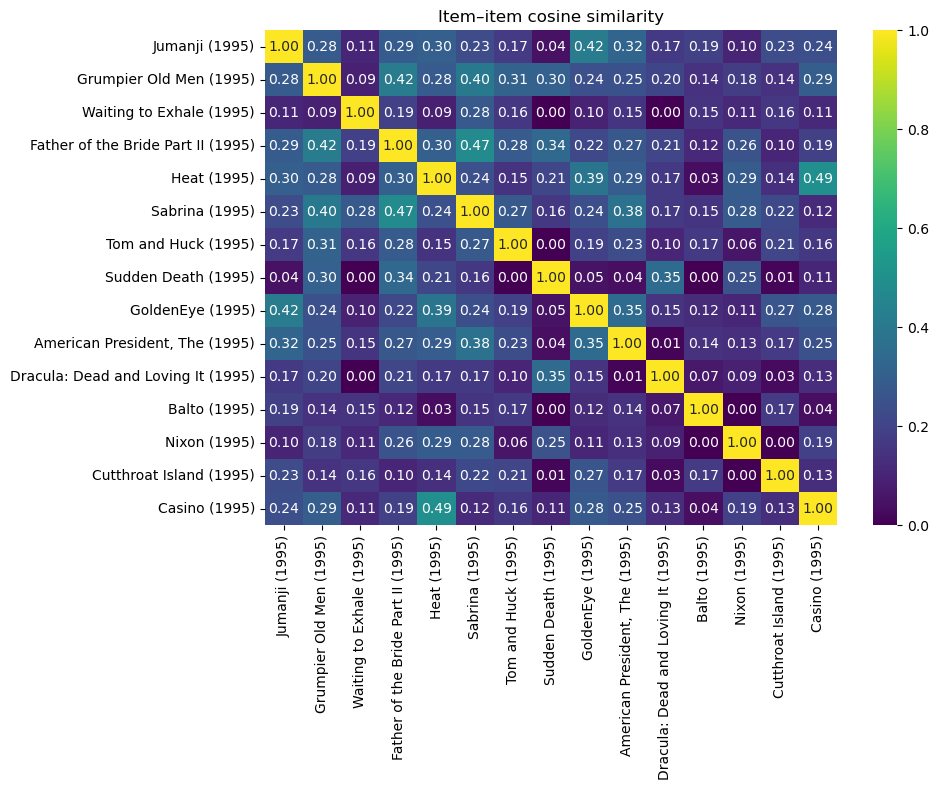

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

picks = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]                       # e.g. positions of some popular movies
labels = [movie_df.set_index('movieId').loc[ratings.columns[p], 'title'] for p in picks]

block = sim_matrix[np.ix_(picks, picks)]   # ??? the NxN sub-matrix — np.ix_ picks a grid

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(block,
            xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".2f",        # show the similarity value in each cell
            cmap="viridis", ax=ax)
ax.set_title("Item–item cosine similarity")
plt.tight_layout()
plt.show()

In [70]:
recommender(10, sim_matrix, N=10) 

,title,genres
movieId,,
54648,Rush Hour 3 (2007),Action|Comedy|Crime|Thriller
120635,Taken 3 (2015),Action|Crime|Thriller
6686,"Medallion, The (2003)",Action|Comedy|Crime|Fantasy
34332,Sky High (2005),Action|Adventure|Children|Comedy
7155,Calendar Girls (2003),Comedy
168418,The Boss Baby (2017),Animation|Children|Comedy
2170,Wrongfully Accused (1998),Action|Comedy
130520,Home (2015),Adventure|Animation|Children|Comedy|Fantasy|Sc...
270,Love Affair (1994),Drama|Romance
